In [1]:
# input, selected from "../../../../human/no_anno/data/human_potential_258.tsv"
hrk_exp_file = "./data/hrk_zn_icp-mass.tsv"
# output
fig_file = "./fig/hrk_zn_icp-mass.pdf"

In [2]:
import pandas as pd
import numpy as np

df = pd.read_table(hrk_exp_file)
data = dict()
data['WT'] = []
for (exp,), df_exp in df.groupby(by=['exp_type']):
    data[exp] = df_exp['ratio'].tolist()

data
categories = data.keys()
means = [np.mean(data[cat]) for cat in categories]
means

{'WT': [0.762633747, 0.849879702],
 'C16A': [0.22627233, 0.252651],
 'C18A': [0.083727823, 0.055556],
 'C2A': [0.204800211, 0.234845],
 'C4A': [0.11639141, 0.056156],
 'all mutant': [0.105866662, 0.154649]}

[np.float64(0.8062567245),
 np.float64(0.239461665),
 np.float64(0.0696419115),
 np.float64(0.2198226055),
 np.float64(0.086273705),
 np.float64(0.130257831)]

In [3]:
categories = ['WT', 'all mutant']
means = [np.mean(data[cat]) for cat in categories]
stds = [np.std(data[cat], ddof=1) for cat in categories]

[Text(0, 0, 'WT'), Text(1, 0, 'all mutant')]

(0.0, 1.0)

Text(0, 0.5, 'Ratio in mol (ion / protein)')

(array([0, 1]), [Text(0, 0, 'WT'), Text(1, 0, 'all mutant')])

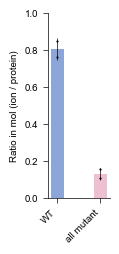

In [5]:
import matplotlib.pyplot as plt


plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(figsize=(0.8, 2.4))

x = np.arange(len(categories))
bar_width = 0.3
bars = ax.bar(x, means, width=bar_width, yerr=stds, color=color_cycle)

for i, cat in enumerate(categories):
    y_vals = data[cat]
    ax.scatter(np.full(len(y_vals), x[i]), y_vals, s=1, c="black")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_ylabel("Ratio in mol (ion / protein)")
plt.xticks(rotation=45, ha='right')

fig.savefig(fig_file, bbox_inches="tight", transparent=True)